# Model Optimization with Gradient Descent

Using a very simple model of diffusivity, we will show how we can use gradient descent to optimize the model parameters.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install matminer
    !pip install torch
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/08-NeuralNetworks"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# Matminer for loading dataset and featurizing
from pymatgen.core import Composition
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementFraction, ElementProperty
from matminer.featurizers.conversions import CompositionToOxidComposition

# Scikit-learn for splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch for neural networks
import torch
import torch.nn as nn

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

In [3]:
df = load_dataset("superconductivity2018")

## Loading and featurizing the dataset with matminer

The dataset does not contain anything - just compositions and critical temperatures!
We will featurize this dataset so we can do some analysis with it.

In [4]:
compositions = []
for formula in df["composition"].values:
    try:
        c = Composition(formula)
        compositions.append(c)
    except ValueError:
        compositions.append(np.nan)
        
df["composition_obj"] = compositions
df = df.dropna()

Below is how we featurize the dataset.
In this Lab, we will not featurize the dataset because it will take a bit of time.
Instead, we will load the pre-featurized datasets that we already computed

In [5]:
# feat = df.copy()
# feat = CompositionToOxidComposition().featurize_dataframe(feat, "composition_obj", ignore_errors=True)
# feat = ElementProperty.from_preset(preset_name="magpie").featurize_dataframe(df, col_id="composition_obj", ignore_errors=True)
# feat.drop("composition_obj", axis=1).to_csv("data/superconductivity2018-features.csv")

In [6]:
feat = pd.read_csv(f"{ROOT}/data/superconductivity2018-features.csv.gz", index_col=0)

## Creating the train-validation-test splits for some ML

In [7]:
# for this example, we will try to find only superconductors (Tc > 0)
superconductors = feat.loc[feat["Tc"] > 0]

# Our label is Tc
y = superconductors["Tc"].values

# Identify feature columns. They are all columns created by the featurizer and 
# are not within the original features
feature_cols = [c for c in superconductors.columns if c not in df.columns]

X = superconductors[feature_cols].values

Let's make a 70:15:15 train-validation-test split

In [8]:
# First split: Train + (Val+Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.7, random_state=564
)

# Second split: Val + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12189
)

print("Train set size:", X_train.shape, "Val set size:", X_val.shape, "Test set size:", X_test.shape)

Train set size: (8708, 132) Val set size: (1866, 132) Test set size: (1866, 132)


Finally, let's rescale the features

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## Defining and training the NN

### First, defining the NN using PyTorch

In [10]:
class TcNet(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.act1 = nn.SiLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = nn.SiLU()
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        
        return x

### Now, we convert everything to a tensor and send it to GPUs

In [11]:
# Convert numpy arrays to torch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# To use GPU if available (optional)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# for Apple Silicon GPU
device = torch.device("mps")

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t   = X_val_t.to(device)
y_val_t   = y_val_t.to(device)

In [12]:
# Instantiate the model
input_dim = X_train.shape[1]
model = TcNet(input_dim=input_dim, hidden1=64, hidden2=32)

# Set up optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model.to(device)

TcNet(
  (fc1): Linear(in_features=132, out_features=64, bias=True)
  (act1): SiLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (act2): SiLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

### Finally, training the models!

In [13]:
# Training hyperparameters
epochs = 8000
train_losses = []
val_losses = []

best_model = None
best_loss = np.inf

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    y_pred_train = model(X_train_t)
    loss_train = criterion(y_pred_train, y_train_t)
    
    # Backpropagation
    loss_train.backward()
    optimizer.step()
    
    train_losses.append(loss_train.item())
    
    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_t)
        loss_val = criterion(y_pred_val, y_val_t)
        val_losses.append(loss_val.item())
        
        if loss_val < best_loss:
            best_loss = loss_val
            best_model = copy.deepcopy(model).cpu()            
    
    # Print progress
    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {loss_train.item():.4f} | Val Loss: {loss_val.item():.4f}")

Epoch [100/8000] | Train Loss: 335.7082 | Val Loss: 328.3144
Epoch [200/8000] | Train Loss: 224.3384 | Val Loss: 232.6505
Epoch [300/8000] | Train Loss: 189.4891 | Val Loss: 200.5228
Epoch [400/8000] | Train Loss: 171.3682 | Val Loss: 181.9192
Epoch [500/8000] | Train Loss: 157.0613 | Val Loss: 168.9723
Epoch [600/8000] | Train Loss: 145.5384 | Val Loss: 157.7071
Epoch [700/8000] | Train Loss: 137.1802 | Val Loss: 150.5900
Epoch [800/8000] | Train Loss: 130.3766 | Val Loss: 145.5600
Epoch [900/8000] | Train Loss: 124.8903 | Val Loss: 142.2408
Epoch [1000/8000] | Train Loss: 120.5047 | Val Loss: 139.2953
Epoch [1100/8000] | Train Loss: 116.4548 | Val Loss: 135.5326
Epoch [1200/8000] | Train Loss: 112.6874 | Val Loss: 132.8472
Epoch [1300/8000] | Train Loss: 109.2022 | Val Loss: 131.5774
Epoch [1400/8000] | Train Loss: 106.0174 | Val Loss: 130.9627
Epoch [1500/8000] | Train Loss: 103.2409 | Val Loss: 130.6447
Epoch [1600/8000] | Train Loss: 100.6720 | Val Loss: 130.1719
Epoch [1700/8000]

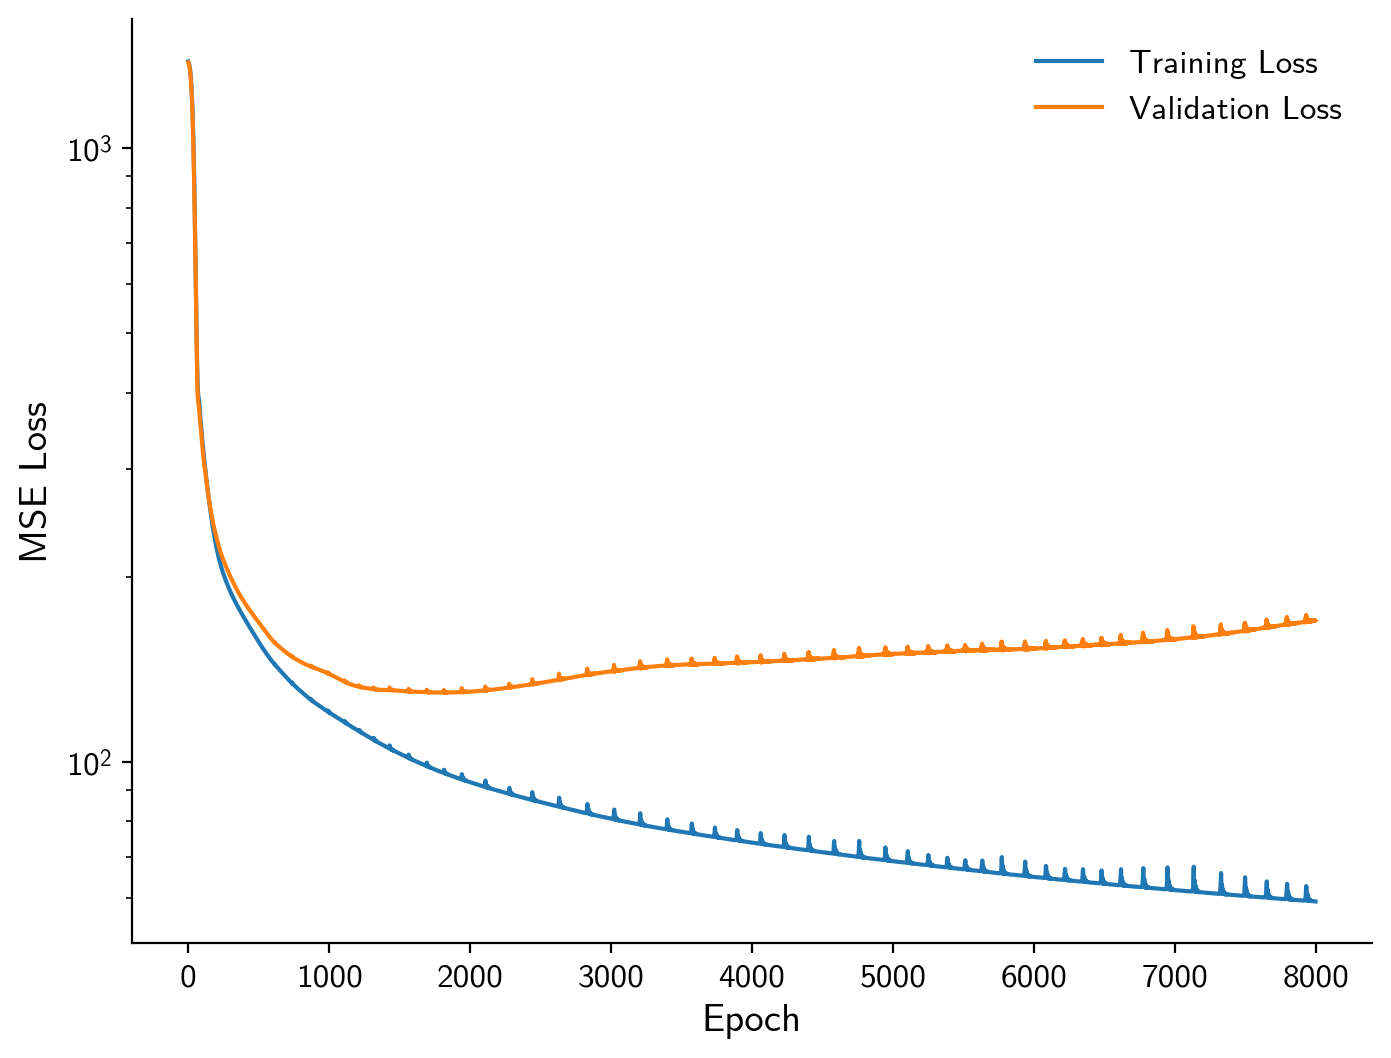

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_losses, label='Training Loss')
ax.plot(val_losses, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(frameon=False)
ax.set_yscale("log")
plt.show()

### Evaluating the performance of the best model

In [15]:
model = best_model
model.to(device)

# Predictions on train and test sets
model.eval()
with torch.no_grad():
    # Training set predictions
    y_pred_train_final = model(X_train_t).cpu().numpy().flatten()
    
    # Test set predictions
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_test_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)
    y_pred_test_final = model(X_test_t).cpu().numpy().flatten()

# Convert the true values to CPU numpy as well if needed
y_train_cpu = y_train_t.cpu().numpy().flatten()
y_test_cpu  = y_test_torch.cpu().numpy().flatten()

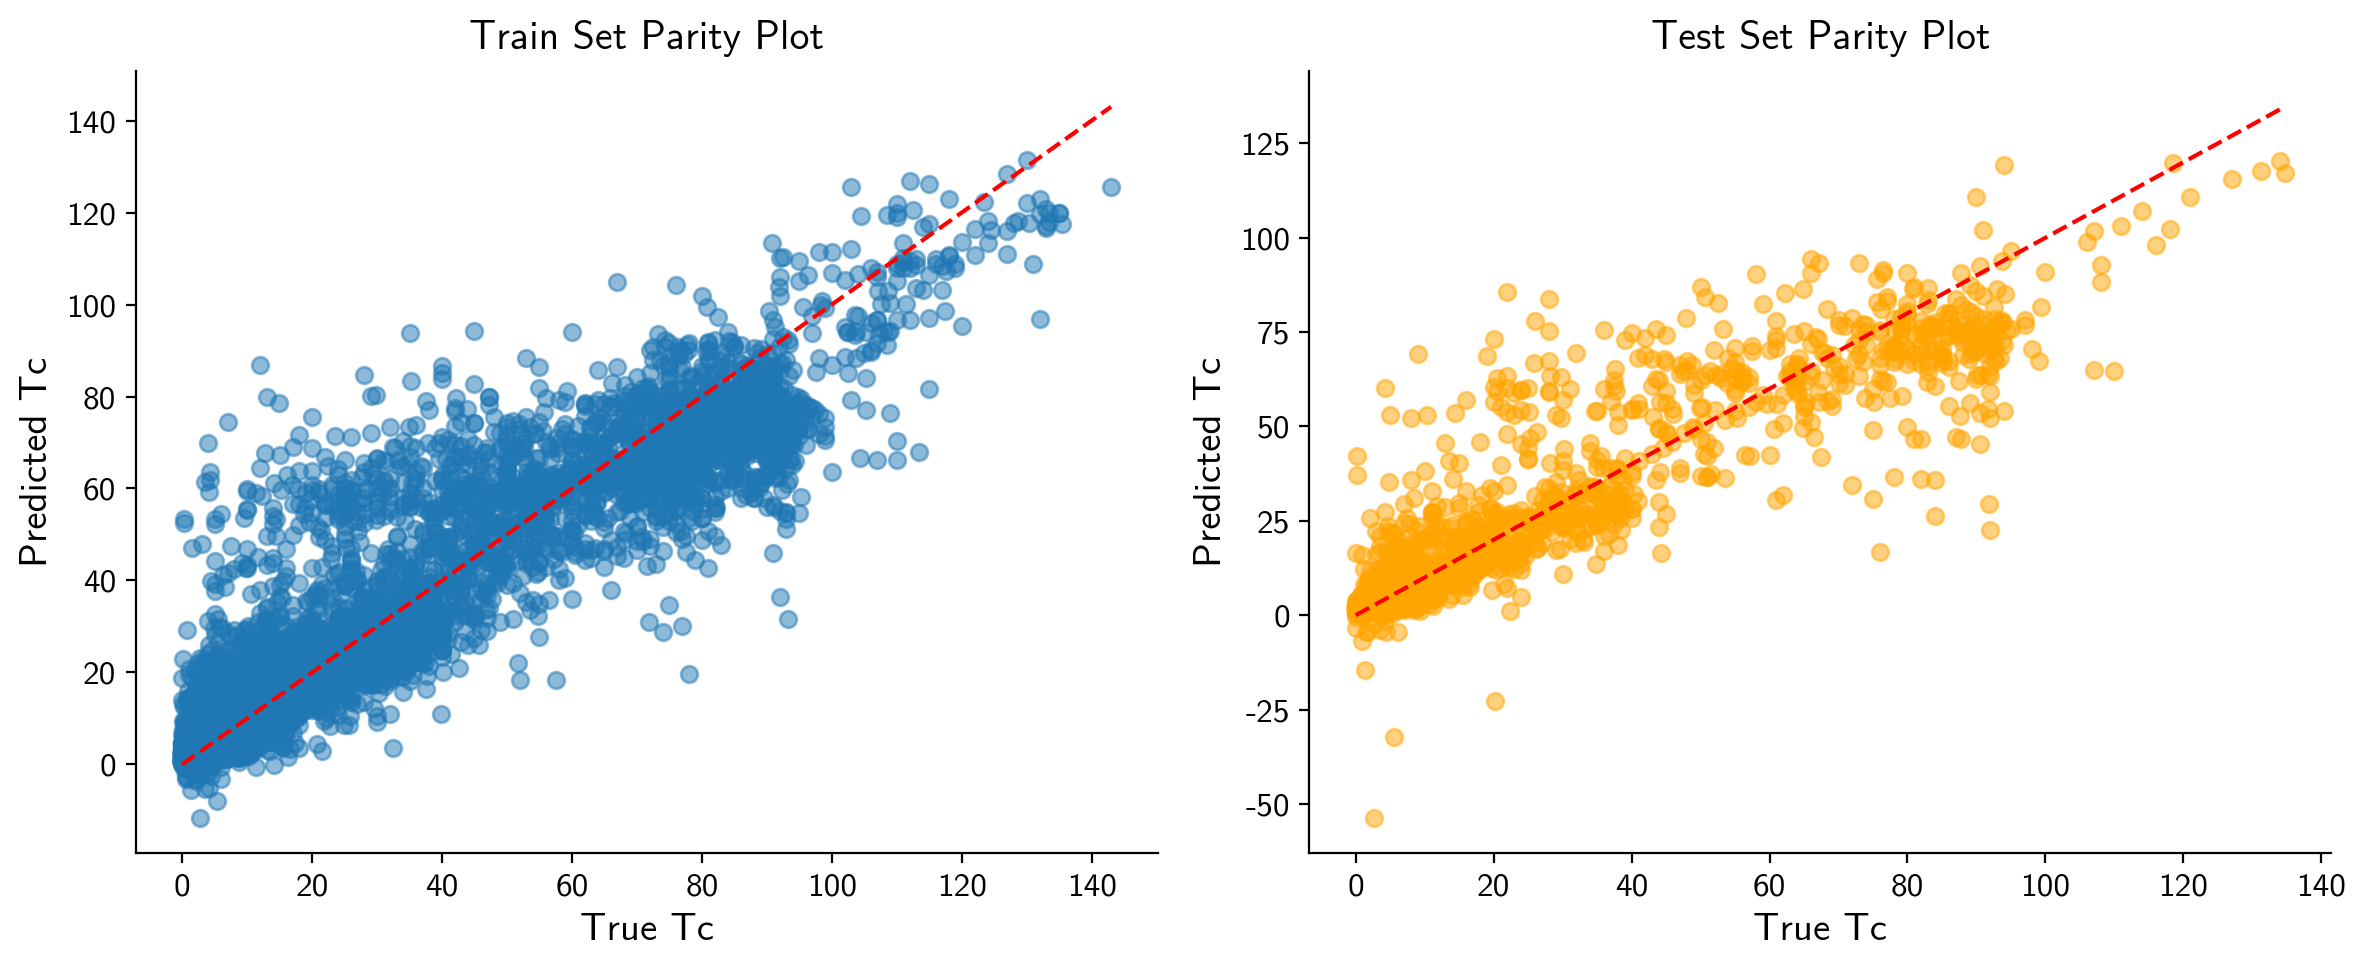

In [16]:
plt.figure(figsize=(12, 5))

# Parity plot for training set
plt.subplot(1, 2, 1)
plt.scatter(y_train_cpu, y_pred_train_final, alpha=0.5, label='Train')
plt.plot([y_train_cpu.min(), y_train_cpu.max()],
         [y_train_cpu.min(), y_train_cpu.max()], 'r--')
plt.title('Train Set Parity Plot')
plt.xlabel('True Tc')
plt.ylabel('Predicted Tc')

# Parity plot for test set
plt.subplot(1, 2, 2)
plt.scatter(y_test_cpu, y_pred_test_final, color='orange', alpha=0.5, label='Test')
plt.plot([y_test_cpu.min(), y_test_cpu.max()],
         [y_test_cpu.min(), y_test_cpu.max()], 'r--')
plt.title('Test Set Parity Plot')
plt.xlabel('True Tc')
plt.ylabel('Predicted Tc')

plt.tight_layout()
plt.show()

In [17]:
# Compute errors
train_mse = mean_squared_error(y_train_cpu, y_pred_train_final)
train_mae = mean_absolute_error(y_train_cpu, y_pred_train_final)
train_r2  = r2_score(y_train_cpu, y_pred_train_final)
train_corr = np.corrcoef(y_train_cpu, y_pred_train_final)[0,1]

test_mse = mean_squared_error(y_test_cpu, y_pred_test_final)
test_mae = mean_absolute_error(y_test_cpu, y_pred_test_final)
test_r2  = r2_score(y_test_cpu, y_pred_test_final)
test_corr = np.corrcoef(y_test_cpu, y_pred_test_final)[0,1]

print("=== Final Metrics ===")
print(f"Train MSE: {train_mse:.3f},  MAE: {train_mae:.3f},  R^2: {train_r2:.3f},  Corr: {train_corr:.3f}")
print(f"Test  MSE: {test_mse:.3f},   MAE: {test_mae:.3f},   R^2: {test_r2:.3f},   Corr: {test_corr:.3f}")

=== Final Metrics ===
Train MSE: 95.847,  MAE: 5.816,  R^2: 0.884,  Corr: 0.940
Test  MSE: 134.148,   MAE: 6.795,   R^2: 0.836,   Corr: 0.915


# Your goal in this Lab:

1. What is our baseline prediction? i.e., do you think a linear regression would do a better job?
2. Do you think you can improve over these predictions by changing the hyperparameters of the NN?